In [1]:
# K-Means Algorithmus ohne library für k-means - mit schrittweiser Anzeige

#   -> Version mit 20 Punkten, siehe: X_df.sample(20, random_state=0)

# Aufgabengenerator: 
#  - ändere "random_state" im Abschnitt "random_state probieren"
#  - ändere die Start-Center Koordinaten im Abschnitt "NEW INIT ..."
#  - Kopiere eine Abbildung in grau nach Powerpoint, siehe den Abschnitt "plot für Aufgabenstellung"
#  - für die Lösung siehe Abbildungen weiter unten

In [2]:
# Quelle / Vorlage
#
# Erweiterter Code auf Basis von J. VanderPlas  (Quelle siehe nächste Zelle)
# 
# Einstellbar ist die Anzahl Diagramme siehe: # <-- Anzahl Diagramme hier einstellen
#
#
# https://jakevdp.github.io/PythonDataScienceHandbook/05.11-k-means.html
# -> Abschnitt:
# "The k-Means algorithm is simple enough that we can write it in a few lines of code. The following is a very basic implementation"

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances_argmin
from sklearn.metrics.pairwise import paired_distances

# tmp
from sklearn.metrics import pairwise_distances

In [4]:
# ---- make data in X ----

from sklearn.datasets import make_blobs
X, y_true = make_blobs(n_samples=300, centers=4,
                       cluster_std=0.60, random_state=0)              # keep the random seed for the same shape of data



In [5]:
# y_true is a 1-dim array containing a label of either: 0, 1, 2, 3
y_true.shape

(300,)

# using pandas DataFrame - VOR sample()

In [6]:
# X is a 2-dim array, let's turn it into a pandas df from the columns of X
X_df = pd.DataFrame({'f1': X[:, 0], 
                     'f2': X[:, 1],})
X_df

,f1,f2
0,0.836857,2.136359
1,-1.413658,7.409623
2,1.155213,5.099619
3,-1.018616,7.814915
4,1.271351,1.892542
...,...,...
295,1.973698,1.579798
296,2.518342,1.391766
297,0.438990,4.535929
298,0.369479,7.791105


# random_state probieren

In [7]:
# sample
X_df = X_df.sample(20, random_state = 2 ).reset_index(drop=True)

In [8]:
# Anzeige NACH sample
X_df.round(3)

,f1,f2
0,0.272,5.470
1,-1.370,7.770
2,0.082,4.567
3,-0.615,3.950
4,0.187,4.027
5,-1.815,3.290
6,1.414,4.381
7,-2.228,6.895
8,1.004,4.191
9,1.782,0.908


In [9]:
# Excel fuer X_df
X_df.round(3).to_excel('output_X_df.xlsx', index=False)

In [10]:
# tmp
X_df.round(3).to_dict('list')

{'f1': [0.272,
  -1.37,
  0.082,
  -0.615,
  0.187,
  -1.815,
  1.414,
  -2.228,
  1.004,
  1.782,
  2.223,
  -1.359,
  -0.513,
  0.277,
  -2.179,
  -0.949,
  -3.122,
  -2.592,
  1.869,
  -1.18],
 'f2': [5.47,
  7.77,
  4.567,
  3.95,
  4.027,
  3.29,
  4.381,
  6.895,
  4.191,
  0.908,
  0.839,
  2.322,
  7.874,
  4.844,
  8.086,
  8.464,
  3.282,
  8.076,
  5.441,
  3.128]}

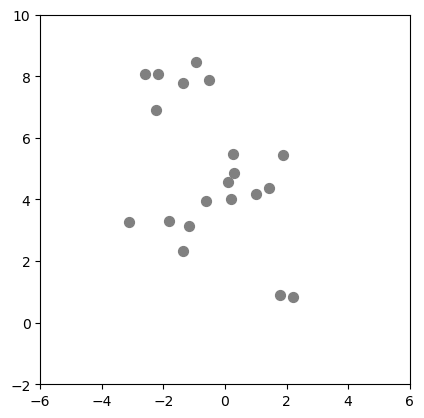

In [11]:
# plot without any info on centers
plt.scatter(X_df.f1, X_df.f2, s=50, c='gray')

# plt.scatter(X[:, 0], X[:, 1], s=50)

plt.gca().set_aspect('equal')
plt.xlim(-6, 6)
plt.ylim(-2, 10)
plt.show()

In [12]:
# going to replace this code using pandas, and our result will be centers_df:

# n_clusters = 4  # from make_blobs

# 1. Randomly choose clusters (hh: to init centers)
# rng = np.random.RandomState(2)                        # hh: random seed (see also make_blobs: random_state)
# i = rng.permutation(X.shape[0])[:n_clusters]
# centers = X[i]
# i

In [13]:
# number of points (total)
n_points = len(X_df)
n_points

20

# NEW INIT manual choice of start centers

In [14]:
# get data points chosen by row_s as an index (so we use .loc)
centers_df = pd.DataFrame({'f1': [0, -3, -2],
                           'f2': [8.5, 7.5, 2]})
init_centers_df = centers_df.copy()
centers_df

# 0 blau
# 1 orange
# 2 grün

,f1,f2
0,0,8.5
1,-3,7.5
2,-2,2.0


In [15]:
centers_df.index.name = 'label'
centers_df

,f1,f2
label,,
0,0,8.5
1,-3,7.5
2,-2,2.0


In [16]:
# tmp
centers_df.to_dict('list')

{'f1': [0, -3, -2], 'f2': [8.5, 7.5, 2.0]}

In [17]:
# Excel fuer cluster
centers_df.to_excel('output_centers.xlsx')    # keep index label column

In [18]:
n_clusters = len(centers_df)

In [19]:
# comparison should be True
# c_n = centers_df.to_numpy()
# np.allclose(centers, c_n)               # alternative usind pandas: df1.equals(df2)

# plot für Aufgabenstellung

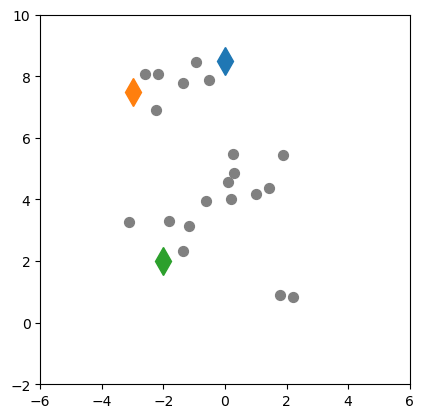

In [20]:
# Aufgabenstellung
plt.scatter(X_df.f1, X_df.f2, s=50, c='gray')

# loop init_centers_df
for i in range(len(init_centers_df)):
    plt.plot(init_centers_df.loc[i, 'f1'], init_centers_df.loc[i, 'f2'], marker='d', linestyle='-', linewidth=5, markersize=14, label=f'Center {i}')

plt.gca().set_aspect('equal')
plt.xlim(-6, 6)
plt.ylim(-2, 10)
plt.show()

### demonstrate using pairwise_distances_argmin()  with two pandas dataframes

In [21]:
# try without loop
# labels1 = pairwise_distances_argmin(X, centers)
# labels1[:15]

In [22]:
# try without loop
labels2 = pairwise_distances_argmin(X_df, centers_df)
labels2[:15]

array([0, 0, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 0, 2, 1])

In [23]:
# comparison should be True
# np.allclose(labels2, labels1)

In [24]:
# convert the result into a pandas series
labels_s = pd.Series(labels2)

# compare to array above
labels_s.head(15).to_list()

[0, 0, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 0, 2, 1]

In [25]:
# name of the series will become a column name
labels_s.name = 'labels'
labels_s.name

'labels'

### end of demonstrating pairwise_distances_argmin() 

In [26]:
labels = labels2

### start making new_centers_df

In [27]:
# old code to replace
  # 2b. Find new centers from means of points
# new_centers = np.array([X[labels == i].mean(0)  for i in range(n_clusters)])
# new_centers

In [28]:
# current centers
centers_df

,f1,f2
label,,
0,0,8.5
1,-3,7.5
2,-2,2.0


In [29]:
# pandas method, we need to combine X_df with labels from pairwise_distances argmin
temp_df = X_df.copy()         # avoid adding a column to X_df
temp_df['label'] = labels_s
temp_df

,f1,f2,label
0,0.272396,5.469960,0
1,-1.369994,7.769530,0
2,0.081516,4.567422,2
3,-0.614907,3.949636,2
4,0.186726,4.026837,2
5,-1.814698,3.290097,2
6,1.413724,4.381177,2
7,-2.227836,6.894799,1
8,1.003725,4.191477,2
9,1.781948,0.908151,2


In [30]:
new_centers_df = temp_df.groupby('label').mean()
new_centers_df

,f1,f2
label,,
0,-0.138150,7.003886
1,-2.332789,7.685670
2,-0.093533,3.310768


In [31]:
# check - "not equal" is ok at the beginning - see below at step "2c. Check for convergence"
if new_centers_df.equals(centers_df):
    print("equal")
else:
    print("not equal")
    print(new_centers_df.compare(centers_df))

not equal
             f1              f2      
           self other      self other
label                                
0     -0.138150     0  7.003886   8.5
1     -2.332789    -3  7.685670   7.5
2     -0.093533    -2  3.310768   2.0


### end of making new_centers_df

In [32]:
# example: from centers index to third column "index"
centers_df.reset_index()

,label,f1,f2
0,0,0,8.5
1,1,-3,7.5
2,2,-2,2.0


4.508638116625243


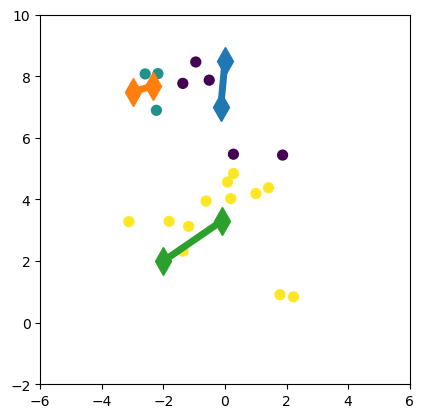

1.5070801350722238


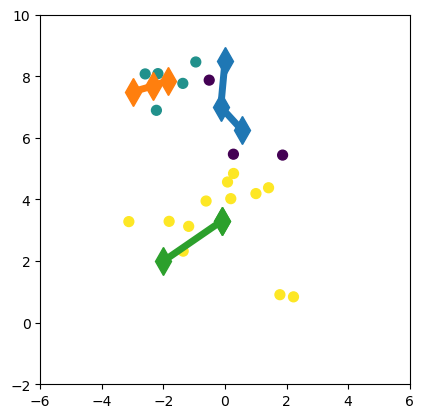

1.4123038784881035


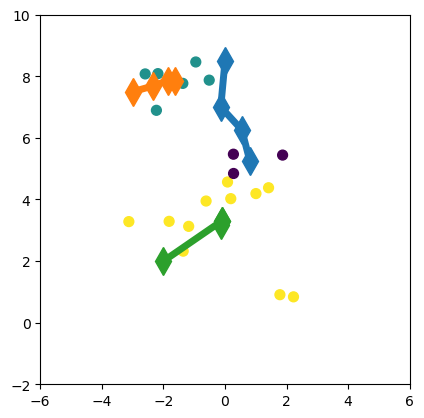

1.0149944262599069


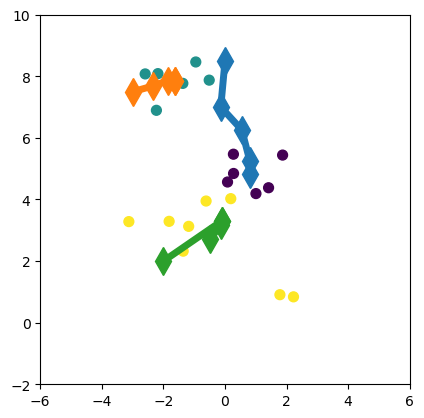

0.3548097441974991


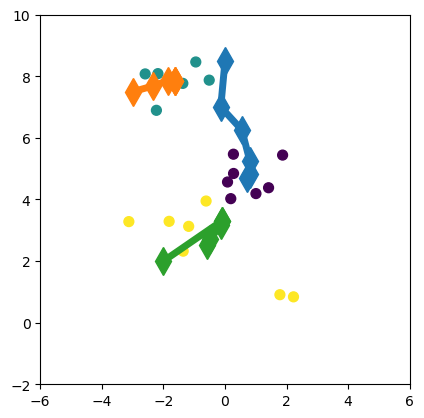

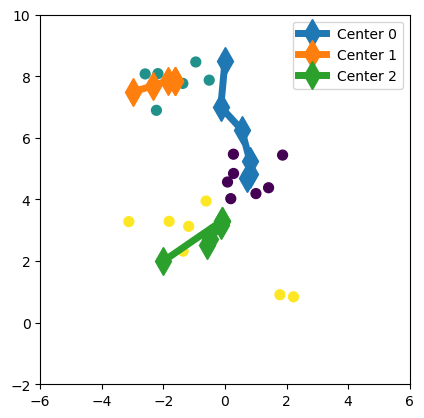

In [33]:
# new function using pandas
counter = 0
centers_trace_lst = [centers_df.reset_index()]   # list starting with a single df, see example above
while True:
    # 2a. Assign labels based on closest center
    labels = pairwise_distances_argmin(X_df, centers_df)
    # labels = pairwise_distances_argmin(X, centers)
    
    # Series
    labels_s = pd.Series(labels)

    # tmp
    # print('--- iteration:', counter, 'labels_s=\n', labels_s)
    # print('---- pairwise_distances:\n')
    # print(pairwise_distances(X_df, centers_df))
      
    # 2b. Find new centers from means of points
    temp_df = X_df.copy()         # avoid adding another column into X_df
    temp_df['label'] = labels_s
    new_centers_df = temp_df.groupby('label').mean()
    # new_centers = np.array([X[labels == i].mean(0)
    #                        for i in range(n_clusters)])
    
    # 2c. Check for convergence
    if new_centers_df.equals(centers_df):
        break
    # if np.all(centers == new_centers):
    #    break

    # write a trace of changes
    print(paired_distances(new_centers_df, centers_df).sum())   # adding four individual distances
    # print(paired_distances(new_centers_df, centers_df))

    centers_df = new_centers_df
    centers_trace_lst.append(centers_df.reset_index())    # see example above

    # trace df from list of dataframes
    c_trace_df = pd.concat(centers_trace_lst, ignore_index=True)

    # plot in a loop
    if counter < 5:                                 # <-- Anzahl Diagramme hier einstellen
        plt.scatter(X_df.f1, X_df.f2, c=labels_s,
            s=50, cmap='viridis');
        for i in range(n_clusters):
            c_df = c_trace_df[c_trace_df['label'] == i]     # filter rows for cluster i -> different color for each i (Center 0 to 3
            plt.plot(c_df.f1, c_df.f2, marker='d', linestyle='-', linewidth=5, markersize=14, label=f'Center {i}')
        plt.gca().set_aspect('equal')
        plt.xlim(-6, 6)
        plt.ylim(-2, 10)
        plt.show()

    counter += 1

# trace df from list of dataframes
c_trace_df = pd.concat(centers_trace_lst, ignore_index=True)

# final diagram
plt.scatter(X_df.f1, X_df.f2, c=labels_s,
            s=50, cmap='viridis');
for i in range(n_clusters):
    c_df = c_trace_df[c_trace_df['label'] == i]     # filter rows for cluster i -> different color for each i (Center 0 to 3
    plt.plot(c_df.f1, c_df.f2, marker='d', linestyle='-', linewidth=5, markersize=14, label=f'Center {i}')
plt.gca().set_aspect('equal')
plt.xlim(-6, 6)
plt.ylim(-2, 10)
plt.legend()
plt.show()

In [34]:
# filter trace by label 0
c_trace_df[c_trace_df['label'] == 0]

,label,f1,f2
0,0,0.000000,8.500000
3,0,-0.138150,7.003886
6,0,0.542761,6.261885
9,0,0.806266,5.251855
12,0,0.819627,4.815940
15,0,0.729213,4.703211


In [35]:
# filter trace by label 1
c_trace_df[c_trace_df['label'] == 1]

,label,f1,f2
1,1,-3.000000,7.500000
4,1,-2.332789,7.685670
7,1,-1.863481,7.858157
10,1,-1.638456,7.860860
13,1,-1.638456,7.860860
16,1,-1.638456,7.860860


In [36]:
# filter trace by label 2
c_trace_df[c_trace_df['label'] == 2]

,label,f1,f2
2,2,-2.000000,2.000000
5,2,-0.093533,3.310768
8,2,-0.093533,3.310768
11,2,-0.127235,3.171357
14,2,-0.487318,2.718106
17,2,-0.583610,2.531145


In [37]:
# display df
X_df

,f1,f2
0,0.272396,5.469960
1,-1.369994,7.769530
2,0.081516,4.567422
3,-0.614907,3.949636
4,0.186726,4.026837
5,-1.814698,3.290097
6,1.413724,4.381177
7,-2.227836,6.894799
8,1.003725,4.191477
9,1.781948,0.908151


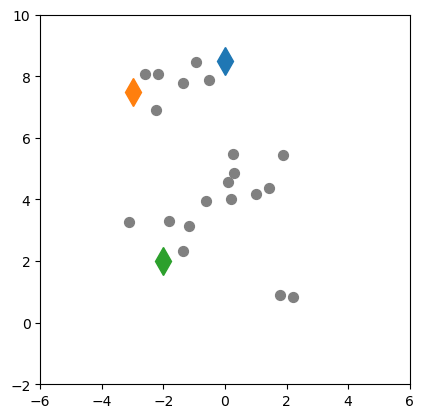

In [38]:
# plot wie ganz oben "Aufgabenstellung"
plt.scatter(X_df.f1, X_df.f2, s=50, c='gray')

# loop init_centers_df
for i in range(len(init_centers_df)):
    plt.plot(init_centers_df.loc[i, 'f1'], init_centers_df.loc[i, 'f2'], marker='d', linestyle='-', linewidth=5, markersize=14, label=f'Center {i}')

plt.gca().set_aspect('equal')
plt.xlim(-6, 6)
plt.ylim(-2, 10)
plt.show()

In [39]:
# confusion matrix - es fehlt y_true bei sample
# pd.crosstab(labels_s, y_true, rownames=['Predicted'], colnames=['True'])

## Result

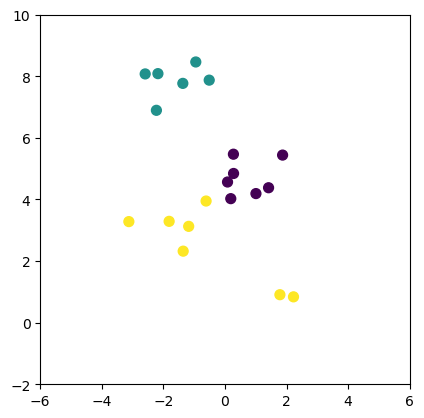

In [40]:
# plot result from clustering, with colors

plt.scatter(X_df.f1, X_df.f2, c=labels_s,
            s=50, cmap='viridis');
plt.gca().set_aspect('equal')
plt.xlim(-6, 6)
plt.ylim(-2, 10)
plt.show()